In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
import scipy
import matplotlib.pyplot as plt
import os

In [12]:
# combined_data.shape  ##Reference_speaker

(9581744, 20)

In [114]:
remove_channels = [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

def remove_drift(signal, fs):
    b, a = scipy.signal.butter(3, 2, 'highpass', fs=fs)
    return scipy.signal.filtfilt(b, a, signal)

def notch(signal, freq, sample_frequency):
    b, a = scipy.signal.iirnotch(freq, 30, sample_frequency)
    return scipy.signal.filtfilt(b, a, signal)

def notch_harmonics(signal, freq, sample_frequency):
    for harmonic in range(1,8):
        signal = notch(signal, freq*harmonic, sample_frequency)
    return signal

def subsample(signal, new_freq, old_freq):
    times = np.arange(len(signal))/old_freq
    sample_times = np.arange(0, times[-1], 1/new_freq)
    result = np.interp(sample_times, times, signal)
    return result

def apply_to_all(function, signal_array, *args, **kwargs):
    results = []
    for i in range(signal_array.shape[1]):
        results.append(function(signal_array[:,i], *args, **kwargs))
    return np.stack(results, 1)

def load_utterance(base_dir, index, limit_length=False, debug=False, text_align_directory=None, is_silent=None):
    index = int(index)
    raw_emg = np.load(os.path.join(base_dir, f'{index}_emg.npy'))
    raw_emg = raw_emg.T  ## Not for Reference_speaker
    raw_emg = apply_to_all(subsample, raw_emg, 1000, 5000)

    
    x = raw_emg
    x = apply_to_all(notch_harmonics, x, 60, 1000)
    x = apply_to_all(remove_drift, x, 1000)
    emg = x

    if emg.shape[1] == 32:
        keep_channels = [i for i in range(emg.shape[1]) if i not in remove_channels]
        emg = emg[:, keep_channels]
        # for c in remove_channels:
        #     emg[:, int(c)] = 0


    return emg

In [9]:
# Directory containing your .npy files
directory_path = 'patient_data/closed_vocab/silent/0/'

# Load and concatenate data from each .npy file
all_data = []
for filename in os.listdir(directory_path):
    if filename.endswith('.npy'):
        data = np.load(directory_path+filename)
        all_data.append(data.T)
        # idx = int(filename.split('_')[0])
        # new_emg = load_utterance(directory_path, idx)
        # all_data.append(new_emg)

# Concatenate all data along the first axis (assuming each file is Tx20)
combined_data = np.concatenate(all_data, axis=0)

In [4]:
data_standardized = combined_data

In [83]:
# Reference_speaker with emg processing
directory_path = 'reference_speaker_data/closed_vocab/silent/0/'

# Load and concatenate data from each .npy file
all_data = []
for filename in os.listdir(directory_path):
    if filename.endswith('.npy'):
        idx = int(filename.split('_')[0])
        new_emg = load_utterance(directory_path, idx)
        all_data.append(new_emg)

# Concatenate all data along the first axis (assuming each file is Tx20)
combined_data = np.concatenate(all_data, axis=0)

In [85]:
reference_speaker_data = combined_data
reference_speaker_data.shape

In [115]:
# Reference_speaker with emg processing
directory_path = 'patient_2_data/closed_vocab/silent/0/'

# Load and concatenate data from each .npy file
all_data = []
for filename in os.listdir(directory_path):
    if filename.endswith('.npy'):
        idx = int(filename.split('_')[0])
        new_emg = load_utterance(directory_path, idx)
        all_data.append(new_emg)

# Concatenate all data along the first axis (assuming each file is Tx20)
combined_data = np.concatenate(all_data, axis=0)

In [116]:
patient_2_data = combined_data
patient_2_data.shape

(2821274, 20)

In [87]:
# Patient with emg processing
directory_path = 'patient_data/closed_vocab/silent/0/'

# Load and concatenate data from each .npy file
all_data = []
for filename in os.listdir(directory_path):
    if filename.endswith('.npy'):
        idx = int(filename.split('_')[0])
        new_emg = load_utterance(directory_path, idx)
        all_data.append(new_emg)

# Concatenate all data along the first axis (assuming each file is Tx20)
combined_data = np.concatenate(all_data, axis=0)

In [88]:
patient_data = combined_data
patient_data.shape

(1636788, 20)

In [90]:
reference_speaker_data.shape

(1883852, 20)

In [24]:
## Reference_speaker without emg processing
directory_path = 'reference_speaker_data/closed_vocab/silent/0/'
all_data = []
for filename in os.listdir(directory_path):
    if filename.endswith('.npy'):
        data = np.load(directory_path+filename)
        all_data.append(data)

# Concatenate all data along the first axis (assuming each file is Tx20)
combined_data_reference_speaker = np.concatenate(all_data, axis=0)

In [22]:
combined_data_reference_speaker.shape

(9418692, 20)

In [11]:
# Standardize the data
scaler = StandardScaler()
data_standardized = scaler.fit_transform(combined_data)

In [16]:
# Patient 2 with emg processing
directory_path = 'patient_2_data/closed_vocab/silent/0/'

# Load and concatenate data from each .npy file
all_data = []
for filename in os.listdir(directory_path):
    if filename.endswith('.npy'):
        idx = int(filename.split('_')[0])
        new_emg = load_utterance(directory_path, idx)
        all_data.append(new_emg)

# Concatenate all data along the first axis (assuming each file is Tx20)
combined_data = np.concatenate(all_data, axis=0)
combined_data = combined_data[:, :20]

In [17]:
combined_data.shape

(2821274, 20)

In [19]:
scaler = StandardScaler()
data_standardized = scaler.fit_transform(combined_data)

## Reference_speaker with emg processing

In [50]:
# Apply PCA
pca = PCA()
data_pca = pca.fit_transform(data_standardized)

# Get the absolute value of the first principal component coefficients
pc1_loadings = np.abs(pca.components_[0])
pc2_loadings = np.abs(pca.components_[1])
pc3_loadings = np.abs(pca.components_[2])
pc4_loadings = np.abs(pca.components_[3])
pc5_loadings = np.abs(pca.components_[4])
pc6_loadings = np.abs(pca.components_[5])
pc7_loadings = np.abs(pca.components_[6])
pc8_loadings = np.abs(pca.components_[7])

# Get the indices of the 8 channels with the highest contribution to PC1
top_channels_1 = np.argsort(pc1_loadings)[-8:][::-1]
top_channels_2 = np.argsort(pc2_loadings)[-8:][::-1]
top_channels_3 = np.argsort(pc3_loadings)[-8:][::-1]
top_channels_4 = np.argsort(pc4_loadings)[-8:][::-1]
top_channels_5 = np.argsort(pc5_loadings)[-8:][::-1]
top_channels_6 = np.argsort(pc6_loadings)[-8:][::-1]
top_channels_7 = np.argsort(pc7_loadings)[-8:][::-1]
top_channels_8 = np.argsort(pc8_loadings)[-8:][::-1]

print("Top 8 channels contributing to PC-1:", top_channels_1)

Top 8 channels contributing to PC-1: [10  5 13  6 16 14  8  3]


In [51]:
print("Top 8 channels contributing to PC-2:", top_channels_2)

Top 8 channels contributing to PC-2: [ 2  3  0  4 11 14 13  5]


In [52]:
print("Top 8 channels contributing to PC-3:", top_channels_3)

Top 8 channels contributing to PC-3: [ 9  1 12  7  0  5  4 16]


In [53]:
print("Top 8 channels contributing to PC-4:", top_channels_4)

Top 8 channels contributing to PC-4: [ 7  8  1 19 18  9  2  4]


In [54]:
print("Top 8 channels contributing to PC-5:", top_channels_5)

Top 8 channels contributing to PC-5: [12  0  9 19 11 18  2  6]


In [55]:
print("Top 8 channels contributing to PC-6:", top_channels_6)

Top 8 channels contributing to PC-6: [19 12  7 18  9 17  2 15]


In [56]:
print("Top 8 channels contributing to PC-7:", top_channels_7)

Top 8 channels contributing to PC-7: [19 18 17 14  7  6 12  2]


In [57]:
print("Top 8 channels contributing to PC-8:", top_channels_8)

Top 8 channels contributing to PC-8: [ 1 17  8  9 11  7  4 10]


## Reference_speaker without emg processing

In [37]:
# Apply PCA
pca = PCA()
data_pca = pca.fit_transform(data_standardized)

# Get the absolute value of the first principal component coefficients
pc1_loadings = np.abs(pca.components_[0])
pc2_loadings = np.abs(pca.components_[1])
pc3_loadings = np.abs(pca.components_[2])
pc4_loadings = np.abs(pca.components_[3])
pc5_loadings = np.abs(pca.components_[4])
pc6_loadings = np.abs(pca.components_[5])
pc7_loadings = np.abs(pca.components_[6])
pc8_loadings = np.abs(pca.components_[7])

# Get the indices of the 8 channels with the highest contribution to PC1
top_channels_1 = np.argsort(pc1_loadings)[-8:][::-1]
top_channels_2 = np.argsort(pc2_loadings)[-8:][::-1]
top_channels_3 = np.argsort(pc3_loadings)[-8:][::-1]
top_channels_4 = np.argsort(pc4_loadings)[-8:][::-1]
top_channels_5 = np.argsort(pc5_loadings)[-8:][::-1]
top_channels_6 = np.argsort(pc6_loadings)[-8:][::-1]
top_channels_7 = np.argsort(pc7_loadings)[-8:][::-1]
top_channels_8 = np.argsort(pc8_loadings)[-8:][::-1]

print("Top 8 channels contributing to PC-1:", top_channels_1)

Top 8 channels contributing to PC-1: [ 4  1 13 10  6  0 11  7]


In [38]:
print("Top 8 channels contributing to PC-2:", top_channels_2)

Top 8 channels contributing to PC-2: [17  3 15 14  5  8  6  0]


In [39]:
print("Top 8 channels contributing to PC-3:", top_channels_3)

Top 8 channels contributing to PC-3: [17  3 15 14  5  8  6  0]


In [40]:
print("Top 8 channels contributing to PC-4:", top_channels_4)

Top 8 channels contributing to PC-4: [15  2  5  8 16  3 19 18]


In [41]:
print("Top 8 channels contributing to PC-5:", top_channels_5)

Top 8 channels contributing to PC-5: [15  2  8  5 17  9  3 12]


In [42]:
print("Top 8 channels contributing to PC-6:", top_channels_6)

Top 8 channels contributing to PC-6: [12  2  8 18  0  1 17 15]


In [43]:
print("Top 8 channels contributing to PC-7:", top_channels_7)

Top 8 channels contributing to PC-7: [18 14 19  2  8 11  6 17]


In [44]:
print("Top 8 channels contributing to PC-8:", top_channels_8)

Top 8 channels contributing to PC-8: [ 9  5  7 15  2 19 16  3]


## Patient

In [12]:
# Apply PCA
pca = PCA()
data_pca = pca.fit_transform(data_standardized)

# Get the absolute value of the first principal component coefficients
pc1_loadings = np.abs(pca.components_[0])
pc2_loadings = np.abs(pca.components_[1])
pc3_loadings = np.abs(pca.components_[2])
pc4_loadings = np.abs(pca.components_[3])
pc5_loadings = np.abs(pca.components_[4])
pc6_loadings = np.abs(pca.components_[5])
pc7_loadings = np.abs(pca.components_[6])
pc8_loadings = np.abs(pca.components_[7])

# Get the indices of the 8 channels with the highest contribution to PC1
top_channels_1 = np.argsort(pc1_loadings)[-8:][::-1]
top_channels_2 = np.argsort(pc2_loadings)[-8:][::-1]
top_channels_3 = np.argsort(pc3_loadings)[-8:][::-1]
top_channels_4 = np.argsort(pc4_loadings)[-8:][::-1]
top_channels_5 = np.argsort(pc5_loadings)[-8:][::-1]
top_channels_6 = np.argsort(pc6_loadings)[-8:][::-1]
top_channels_7 = np.argsort(pc7_loadings)[-8:][::-1]
top_channels_8 = np.argsort(pc8_loadings)[-8:][::-1]

print("Top 8 channels contributing to PC-1:", top_channels_1)

Top 8 channels contributing to PC-1: [ 5  9  8  6 14 15 12 18]


In [70]:
np.sort(pc1_loadings)[-8:][::-1]

array([0.35757356, 0.34262942, 0.3410008 , 0.33196457, 0.32257909,
       0.31798247, 0.29924039, 0.22419075])

In [66]:
print("Top 8 channels contributing to PC-2:", top_channels_2) #  6  3  5 18  8  0  9  4

Top 8 channels contributing to PC-2: [ 6  3  5 18  8  0  9  4]


In [71]:
np.sort(pc2_loadings)[-8:][::-1]

array([0.44202518, 0.41231293, 0.39177207, 0.36989757, 0.33063183,
       0.24222462, 0.22876529, 0.21692204])

In [28]:
print("Top 8 channels contributing to PC-3:", top_channels_3)

Top 8 channels contributing to PC-3: [ 4 18  0  5  8  3  6  9]


In [72]:
np.sort(pc3_loadings)[-8:][::-1]

array([0.47398061, 0.4280272 , 0.41736049, 0.34019419, 0.25690758,
       0.24932909, 0.19320527, 0.17046488])

In [29]:
print("Top 8 channels contributing to PC-4:", top_channels_4)

Top 8 channels contributing to PC-4: [10  7 17 15 14  9 13  2]


In [73]:
np.sort(pc4_loadings)[-8:][::-1]

array([0.64252695, 0.62025789, 0.24054687, 0.16167658, 0.15746195,
       0.15744123, 0.15147279, 0.14582438])

In [67]:
print("Top 8 channels contributing to PC-5:", top_channels_5) # 19  1  2  7  4  8  9 15

Top 8 channels contributing to PC-5: [ 1  2  7  4  8  9 15  3]


In [74]:
np.sort(pc5_loadings)[-8:][::-1]

array([0.9904401 , 0.10215999, 0.05505334, 0.04400614, 0.03908226,
       0.0215918 , 0.0206507 , 0.01728753])

In [68]:
print("Top 8 channels contributing to PC-6:", top_channels_6) # 1 19  2  7  4  8  3  6

Top 8 channels contributing to PC-6: [ 2  7  8  4  1 17  9 10]


In [75]:
np.sort(pc6_loadings)[-8:][::-1]

array([0.85577744, 0.36767197, 0.16525236, 0.16122312, 0.13073743,
       0.11822945, 0.1112618 , 0.09818005])

In [32]:
print("Top 8 channels contributing to PC-7:", top_channels_7)

Top 8 channels contributing to PC-7: [ 2  7  8  4  1 17  9 10]


In [33]:
print("Top 8 channels contributing to PC-8:", top_channels_8)

Top 8 channels contributing to PC-8: [ 4  8  9  2  5 18  3  7]


# Patient 2

In [20]:
# Apply PCA
pca = PCA()
data_pca = pca.fit_transform(data_standardized)

# Get the absolute value of the first principal component coefficients
pc1_loadings = np.abs(pca.components_[0])
pc2_loadings = np.abs(pca.components_[1])
pc3_loadings = np.abs(pca.components_[2])
pc4_loadings = np.abs(pca.components_[3])
pc5_loadings = np.abs(pca.components_[4])
pc6_loadings = np.abs(pca.components_[5])
pc7_loadings = np.abs(pca.components_[6])
pc8_loadings = np.abs(pca.components_[7])

# Get the indices of the 8 channels with the highest contribution to PC1
top_channels_1 = np.argsort(pc1_loadings)[-8:][::-1]
top_channels_2 = np.argsort(pc2_loadings)[-8:][::-1]
top_channels_3 = np.argsort(pc3_loadings)[-8:][::-1]
top_channels_4 = np.argsort(pc4_loadings)[-8:][::-1]
top_channels_5 = np.argsort(pc5_loadings)[-8:][::-1]
top_channels_6 = np.argsort(pc6_loadings)[-8:][::-1]
top_channels_7 = np.argsort(pc7_loadings)[-8:][::-1]
top_channels_8 = np.argsort(pc8_loadings)[-8:][::-1]

print("Top 8 channels contributing to PC-1:", top_channels_1)

Top 8 channels contributing to PC-1: [ 3  5  9  4 14 13 18  2]


In [45]:
from gtts import gTTS
import io
from pydub import AudioSegment
from pydub.playback import play

def text_to_speech(text, lang='en'):
    try:
        # Create a gTTS object
        tts = gTTS(text=text, lang=lang)
        
        # Save the audio to a BytesIO object
        audio_data = io.BytesIO()
        tts.write_to_fp(audio_data)
        audio_data.seek(0)  # Rewind the file pointer to the beginning
        
        # with open("output_audio.mp3", "wb") as out:
        #     out.write(audio_data.getvalue())

        # Load the audio data with pydub
        # audio_segment = AudioSegment.from_file(audio_data, format="mp3")
        
        return audio_data.getvalue()
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Example usage
text = "Hello, this is a test of the Google Text-to-Speech API."
audio = text_to_speech(text)

# Play the audio (optional)
if audio:
    play(audio)


b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xf3\x84\xc4\x00\x00\x00\x03H\x01@\x00\x00\xff1 \x82\xd0\x13\x8e\t\x04w\xa8h\xa4\xd4\x19\t?\xed!\x826\xcd\xe7\t\xd9M\x01\x98!D\x8f\x85\xec{\x9b\xa0\x01\xa0\xa6#\x02/\xed%\x1aD\x1b\x06@\x9c\x17\x7f@\xc1\x05\xa6\xe3\xf1\xd1\xc6]

AttributeError: 'bytes' object has no attribute 'export'

In [33]:
!pip install playsound

  Preparing metadata (setup.py) ... done
  Created wheel for playsound: filename=playsound-1.3.0-py3-none-any.whl size=7020 sha256=b7f0af9eb9daec6b75d9a257ed17732eb7e89612628fbcff847da3042a3aef71
  Stored in directory: /home/nkaushal/.cache/pip/wheels/73/cd/cf/9750b618d54bd81c20e4c34fb24a423a5b095920367cdb3f71
Successfully built playsound
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [35]:
from gtts import gTTS
from playsound import playsound

def test_gtts(text, lang='en', filename='output.flac'):
    try:
        # Create a gTTS object
        tts = gTTS(text=text, lang=lang)
        
        # Save the audio to a file
        tts.save(filename)
        
        # Play the audio file
        playsound(filename)
        
        print(f"Audio saved and played as {filename}")
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage
text = "Hello, this is a test of the Google Text-to-Speech API."
test_gtts(text)


Audio saved and played as output.flac


In [46]:
from gtts import gTTS
from playsound import playsound
import os

def convert_transcripts_to_audio(directory):
    try:
        # Ensure the directory exists
        if not os.path.exists(directory):
            print(f"Directory {directory} not found.")
            return

        # List all files in the directory
        for filename in os.listdir(directory):
            if filename.endswith("_info.txt"):
                # Construct full path to the text file
                file_path = os.path.join(directory, filename)

                # Read the text from the file
                with open(file_path, 'r', encoding='utf-8') as file:
                    text = file.read()

                # Define the output audio file name
                number = filename.split('_')[0]
                audio_file = os.path.join(directory, f"{number}_audio.flac")

                # Create a gTTS object and save to the specified format
                tts = gTTS(text=text, lang='en')
                tts.save(audio_file)

                # Play the audio file (optional)
                # playsound(audio_file)

                # print(f"Audio saved and played as {audio_file}")
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage
directory = 'patient_data/closed_vocab/voiced/0/'
convert_transcripts_to_audio(directory)


Audio saved and played as patient_data/closed_vocab/voiced/0/390_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/248_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/117_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/218_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/400_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/207_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/319_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/353_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/152_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/163_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/188_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/213_audio.flac
Audio saved and played as patient_data/closed_vocab/voiced/0/264_audio.flac
Audio saved 

In [47]:
import librosa as lb

In [48]:
aud, sr = lb.load('patient_data/closed_vocab/voiced/0/160_audio.flac')

In [49]:
sr

22050

In [125]:
patient_emg_1 = np.load('patient_data/closed_vocab/silent/0/50_emg.npy')
reference_speaker_emg_1 = np.load('reference_speaker_data/closed_vocab/silent/0/50_emg.npy')

In [126]:
patient_emg_1 = patient_emg_1.T

In [127]:
patient_emg_1.shape

(23856, 20)

In [128]:
reference_speaker_emg_1.shape

(22574, 20)

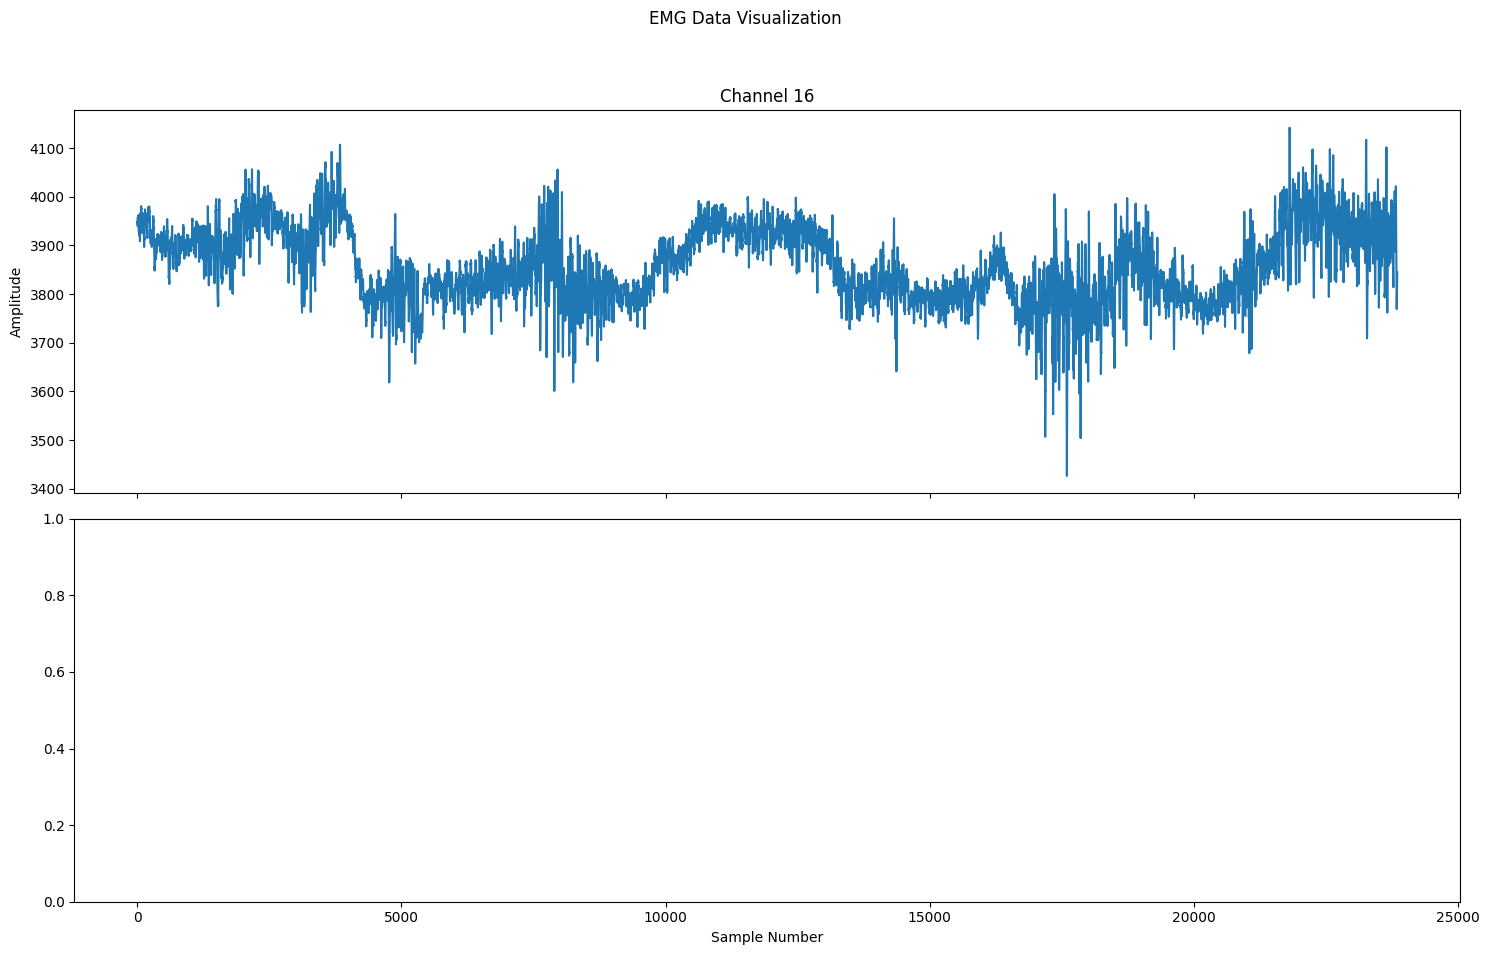

In [129]:
# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Set the title for the entire figure
fig.suptitle('EMG Data Visualization')

# Loop through each channel
axis = 0
for i in range(1):
    # Plot each channel on a separate subplot
    # if i not in remove_channels:
    axs[axis].plot(patient_emg_1[:, 12])
    axs[axis].set_title(f'Channel {16}')
    axs[axis].set_ylabel('Amplitude')
    axis += 1

# Set common labels
plt.xlabel('Sample Number')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()

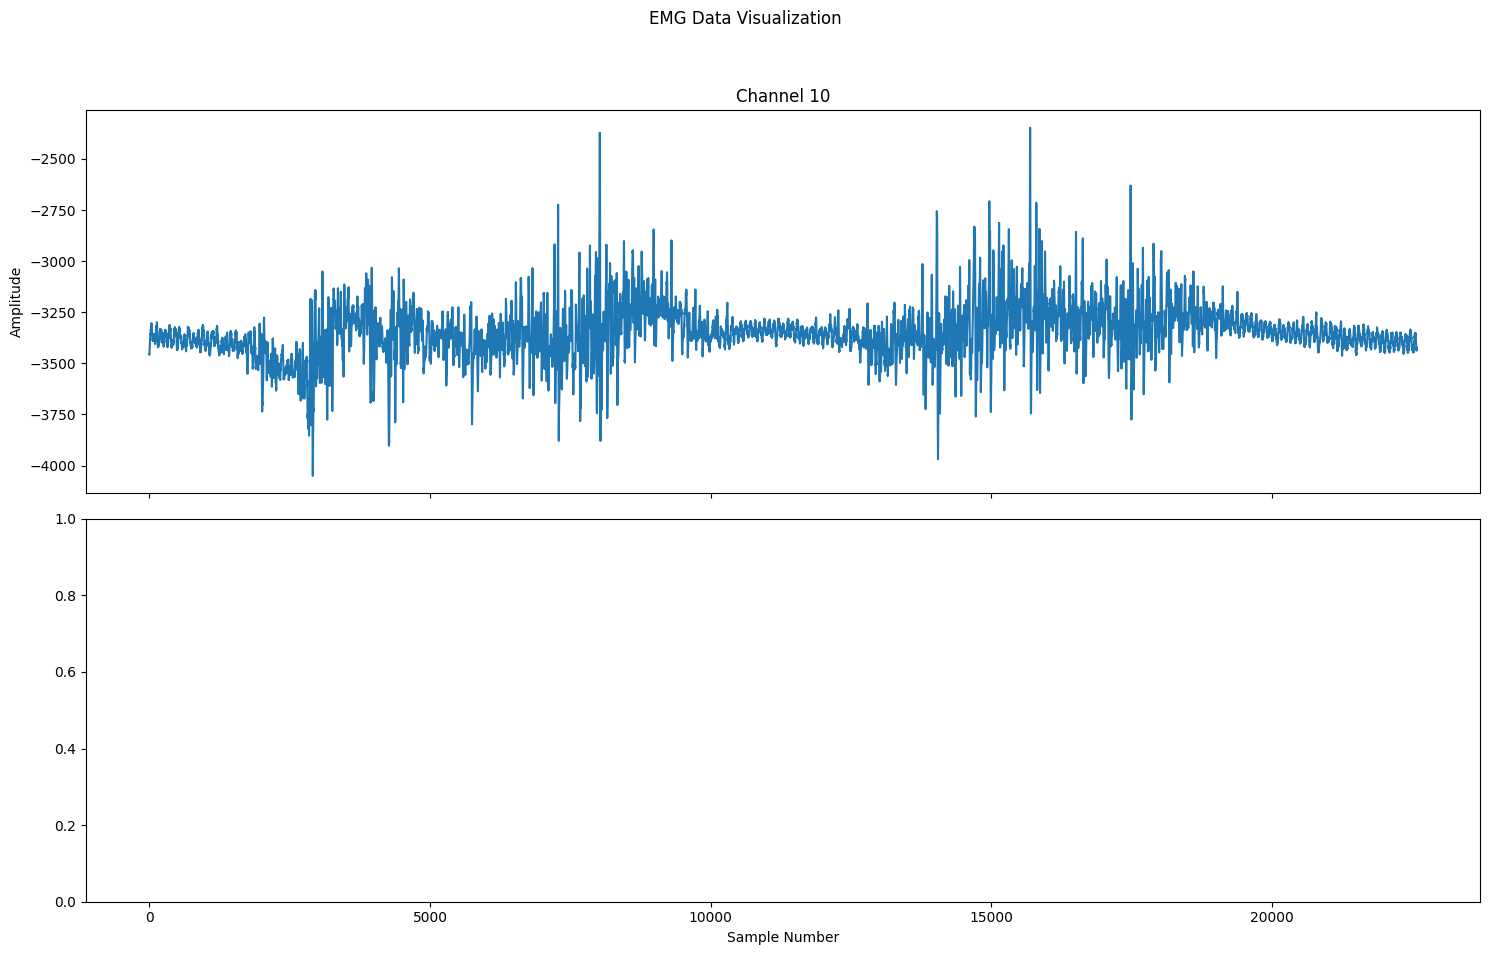

In [130]:
# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Set the title for the entire figure
fig.suptitle('EMG Data Visualization')

# Loop through each channel
axis = 0
for i in range(1):
    # Plot each channel on a separate subplot
    # if i not in remove_channels:
    axs[axis].plot(reference_speaker_emg_1[:, 9])
    axs[axis].set_title(f'Channel {10}')
    axs[axis].set_ylabel('Amplitude')
    axis += 1

# Set common labels
plt.xlabel('Sample Number')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()

In [117]:
import numpy as np

# Load your data
# data_healthy = np.load('reference_speaker_data/closed_vocab/silent/0/100_emg.npy')
# data_laryngectomy = np.load('patient_data/closed_vocab/silent/0/100_emg.npy')
# data_laryngectomy = data_laryngectomy.T

# Determine the maximum length
max_length = max(reference_speaker_data.shape[0], patient_2_data.shape[0])

# Pad the shorter signal with zeros
data_healthy_padded = np.pad(reference_speaker_data, ((0, max_length - reference_speaker_data.shape[0]), (0, 0)), 'constant')
data_laryngectomy_padded = np.pad(patient_data, ((0, max_length - patient_data.shape[0]), (0, 0)), 'constant')


# Calculate the correlation matrix between each channel of the two datasets
correlation_matrix = np.corrcoef(data_healthy_padded.T, data_laryngectomy_padded.T)[:19, 20:-1]

# Finding the best matching channels
best_matches = np.argmax(correlation_matrix, axis=1)

# Print the matching channels
for i, match in enumerate(best_matches):
    print(f"Channel {i+1} in healthy corresponds to Channel {match+1} in laryngectomy patient")


Channel 1 in healthy corresponds to Channel 2 in laryngectomy patient
Channel 2 in healthy corresponds to Channel 7 in laryngectomy patient
Channel 3 in healthy corresponds to Channel 2 in laryngectomy patient
Channel 4 in healthy corresponds to Channel 3 in laryngectomy patient
Channel 5 in healthy corresponds to Channel 2 in laryngectomy patient
Channel 6 in healthy corresponds to Channel 2 in laryngectomy patient
Channel 7 in healthy corresponds to Channel 3 in laryngectomy patient
Channel 8 in healthy corresponds to Channel 3 in laryngectomy patient
Channel 9 in healthy corresponds to Channel 2 in laryngectomy patient
Channel 10 in healthy corresponds to Channel 14 in laryngectomy patient
Channel 11 in healthy corresponds to Channel 3 in laryngectomy patient
Channel 12 in healthy corresponds to Channel 16 in laryngectomy patient
Channel 13 in healthy corresponds to Channel 16 in laryngectomy patient
Channel 14 in healthy corresponds to Channel 16 in laryngectomy patient
Channel 15 

In [101]:
import seaborn as sns

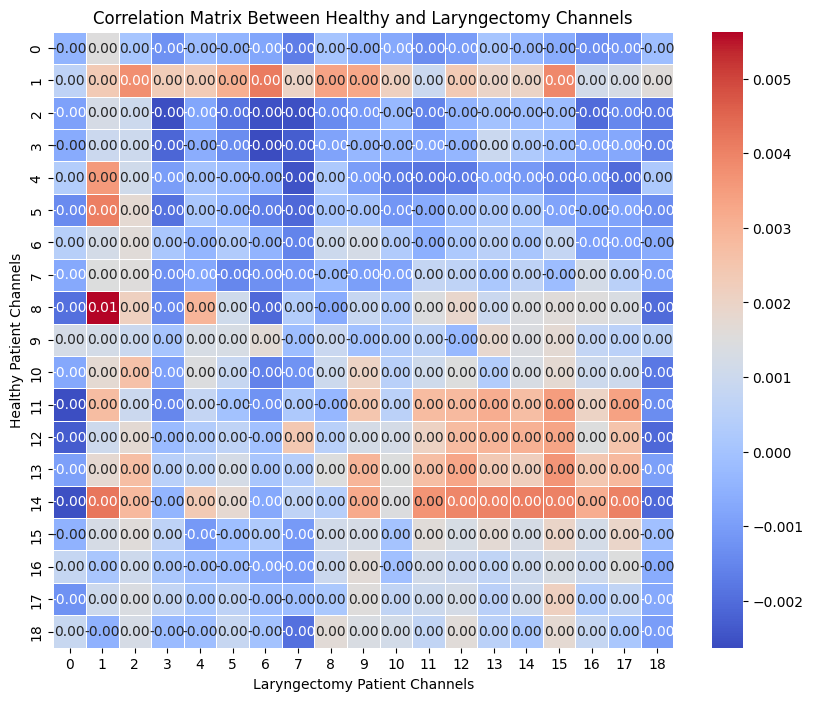

In [102]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Between Healthy and Laryngectomy Channels')
plt.xlabel('Laryngectomy Patient Channels')
plt.ylabel('Healthy Patient Channels')
plt.show()

In [118]:
## patient_2 vs reference_speaker

import numpy as np

# Load your data
# data_healthy = np.load('reference_speaker_data/closed_vocab/silent/0/100_emg.npy')
# data_laryngectomy = np.load('patient_data/closed_vocab/silent/0/100_emg.npy')
# data_laryngectomy = data_laryngectomy.T

# Determine the maximum length
max_length = max(reference_speaker_data.shape[0], patient_2_data.shape[0])

# Pad the shorter signal with zeros
data_healthy_padded = np.pad(reference_speaker_data, ((0, max_length - reference_speaker_data.shape[0]), (0, 0)), 'constant')
data_laryngectomy_padded = np.pad(patient_2_data, ((0, max_length - patient_2_data.shape[0]), (0, 0)), 'constant')


# Calculate the correlation matrix between each channel of the two datasets
correlation_matrix = np.corrcoef(data_healthy_padded.T, data_laryngectomy_padded.T)[:19, 20:-1]

# Finding the best matching channels
best_matches = np.argmax(correlation_matrix, axis=1)

# Print the matching channels
for i, match in enumerate(best_matches):
    print(f"Channel {i+1} in healthy corresponds to Channel {match+1} in laryngectomy patient")


Channel 1 in healthy corresponds to Channel 18 in laryngectomy patient
Channel 2 in healthy corresponds to Channel 7 in laryngectomy patient
Channel 3 in healthy corresponds to Channel 1 in laryngectomy patient
Channel 4 in healthy corresponds to Channel 1 in laryngectomy patient
Channel 5 in healthy corresponds to Channel 2 in laryngectomy patient
Channel 6 in healthy corresponds to Channel 1 in laryngectomy patient
Channel 7 in healthy corresponds to Channel 1 in laryngectomy patient
Channel 8 in healthy corresponds to Channel 12 in laryngectomy patient
Channel 9 in healthy corresponds to Channel 1 in laryngectomy patient
Channel 10 in healthy corresponds to Channel 18 in laryngectomy patient
Channel 11 in healthy corresponds to Channel 1 in laryngectomy patient
Channel 12 in healthy corresponds to Channel 12 in laryngectomy patient
Channel 13 in healthy corresponds to Channel 7 in laryngectomy patient
Channel 14 in healthy corresponds to Channel 1 in laryngectomy patient
Channel 15 

In [123]:
patient_2_emg_1 = np.load('patient_2_data/closed_vocab/silent/0/50_emg.npy')
patient_2_emg_1 = patient_2_emg_1.T

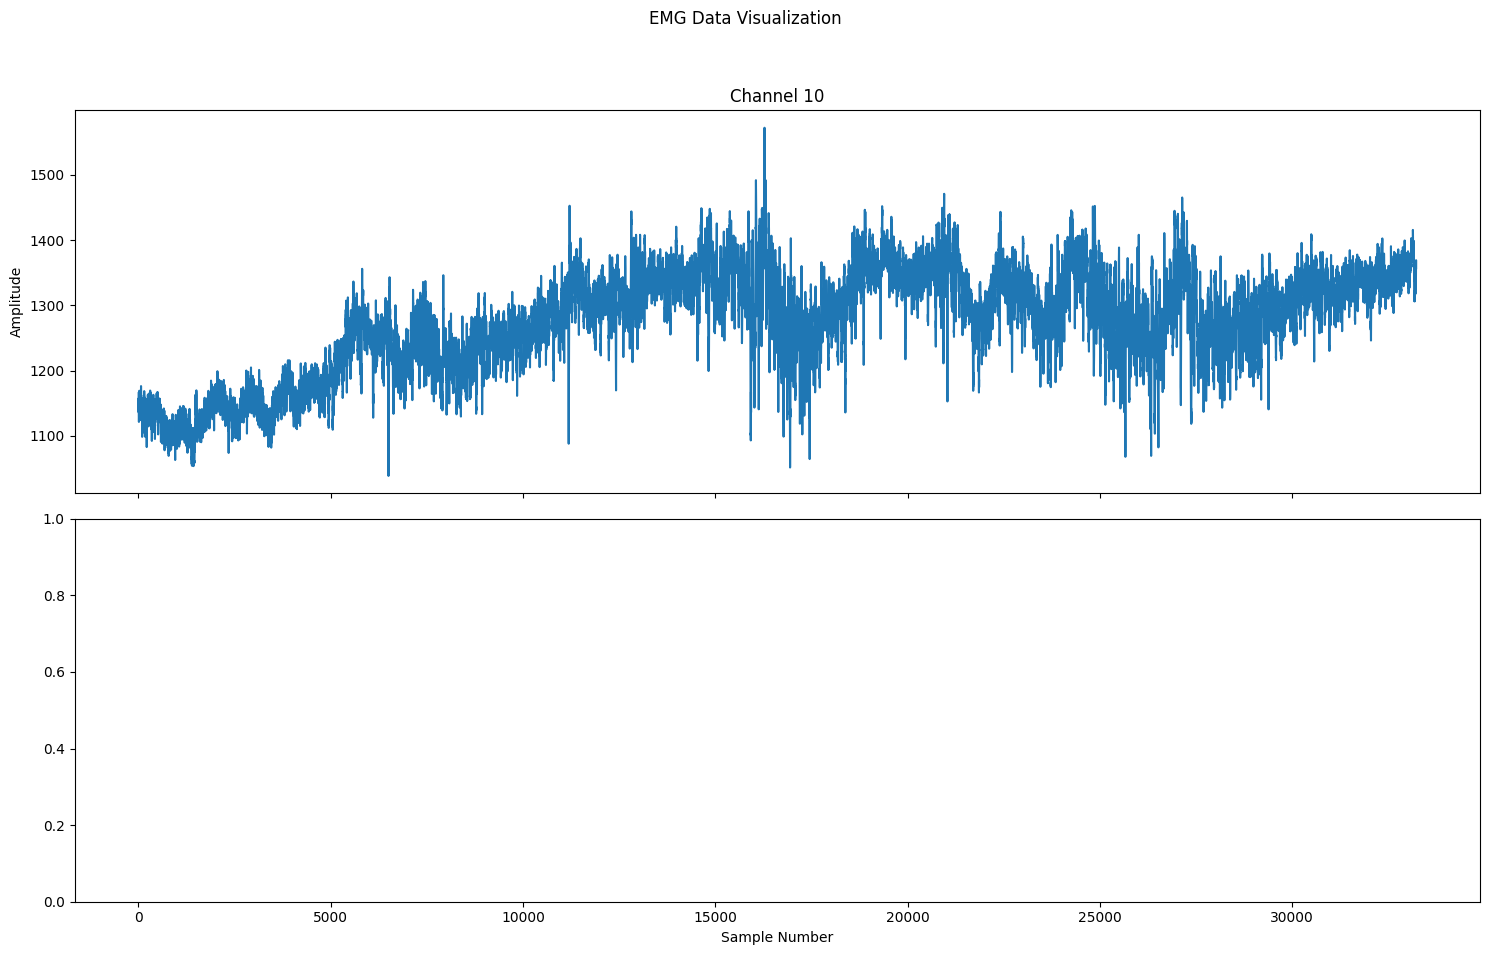

In [124]:
# Create a figure and a set of subplots
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Set the title for the entire figure
fig.suptitle('EMG Data Visualization')

# Loop through each channel
axis = 0
for i in range(1):
    # Plot each channel on a separate subplot
    # if i not in remove_channels:
    axs[axis].plot(patient_2_emg_1[:, 11])
    axs[axis].set_title(f'Channel {10}')
    axs[axis].set_ylabel('Amplitude')
    axis += 1

# Set common labels
plt.xlabel('Sample Number')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the plot
plt.show()